In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import random

from time import time

from scipy.special import comb, loggamma, lambertw
from scipy.stats import multinomial, expon

import lifelines
from lifelines.utils import concordance_index
from lifelines.statistics import logrank_test

from silence_tensorflow import silence_tensorflow
silence_tensorflow()
import tensorflow as tf
import tensorflow_probability as tfp
from tensorflow import keras
from tensorflow.keras import optimizers, initializers, regularizers, layers

config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config = config)

import os, shutil
from pathlib import Path
import json
import subprocess

import thetaflow as thf
# import modelnn2 as thf
print("Thetaflow version: {}".format(thf.__version__))

import mpscr_models as mpscr
import pwexp
import gndr_utils as utils
import mps

I0000 00:00:1783575651.991068   28260 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783575653.787177   28260 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Thetaflow version: 0.0.35


/home/natan/.pyenv/versions/3.10.16/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
a0 = 1.0
p_min = 0.0
p_max = 1.0
sup = np.arange(501)

def log_a(m, q):
    return -tf.math.lgamma(m+1)

def a(m, q):
    return tf.math.exp( log_a(m, q) )

# For the Poisson, a0 is always equal to 1.0, as there is no second parameter, q
def a0(q):
    return 1.0

def phi(theta, q):
    return tf.identity(theta)

def log_phi(theta, q):
    return tf.math.log(theta)
                       
def phi_inv(u, q):
    return tf.identity(u)

def C(theta, q):
    return tf.math.exp(theta)

def C_inv(u, q):
    return tf.math.log(u)

def A(u, q):
    theta = phi_inv(u, q)
    return C(theta, q)

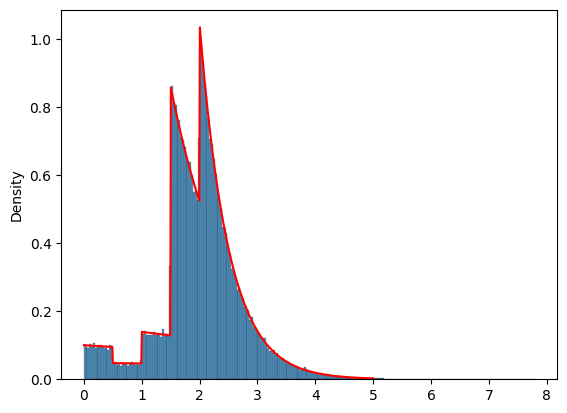

In [3]:
alpha = np.array([0.1, 0.05, 0.15, 1, 2])
s = np.array([0,0.5,1,1.5,2])
t = np.linspace(0.001, 5, 500)

h_t = pwexp.h(t, alpha, s)
H_t = pwexp.ch(t, alpha, s)
F_t = pwexp.cdf(t, alpha, s, lower_tail = True)
f_t = pwexp.pdf(t, alpha, s)
F_inv_t = pwexp.ppf(F_t, alpha, s)

sample_t = pwexp.rvs(alpha, s, size = 100000)

sns.histplot(x = sample_t, stat = "density")
plt.plot(t, f_t, color = "red")
# plt.plot(t, F_t)
# plt.plot(F_t, F_inv_t)
# plt.plot([0,np.max(t)], [0, np.max(t)])
plt.show()

To validate the implementation of our general model, we consider a simple data generating scheme with a single predictor variable, $x$.

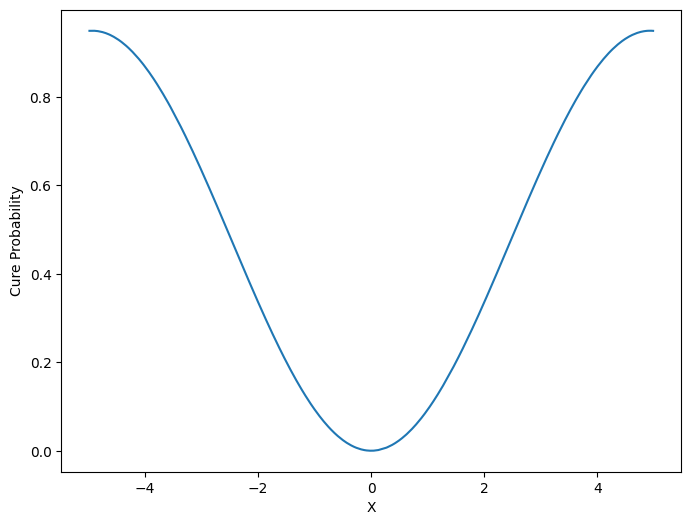

In [4]:
n = 500

x = np.random.uniform(size = n, low = -5.0, high = 5.0)

p_true = np.sin(x / np.pi)**2 * 0.95

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))
sns.lineplot(x = x, y = p_true, ax = ax)
ax.set_xlabel("X")
ax.set_ylabel("Cure Probability")
plt.show()

We consider the latent variables to follow a Poisson distribution merged with a standard Exp(1) distribution as a base distribution, $S_0$.

In [5]:
np.random.seed(10)

n_train = 400
n_test = 100

x_train = np.random.uniform(size = n_train, low = -5.0, high = 5.0)
x_test = np.random.uniform(size = n_test, low = -5.0, high = 5.0)

p_true_train = np.sin(x_train / np.pi)**2 * 0.95
p_true_test = np.sin(x_test / np.pi)**2 * 0.95

# theta = C^{-1}( a0 / p )
# For the Poisson, we have C(theta) = e^theta, a0 = 1.0
theta_train = np.log( 1.0 / p_true_train )
theta_test = np.log( 1.0 / p_true_test )
q = 0.0

# m = np.random.poisson(size = n, lam = theta)
m_train = mps.rvs(log_a, log_phi, theta_train, q, sup).numpy()
m_test = mps.rvs(log_a, log_phi, theta_test, q, sup).numpy()
cured_train = (m_train == 0).astype("int")
cured_test = (m_test == 0).astype("int")

# Random uniform generators for the true lifetimes
u_train = np.random.uniform(size = np.sum(m_train > 0) )
u_test = np.random.uniform(size = np.sum(m_test > 0) )
# True lifetimes
y_true_train = np.repeat(np.inf, n_train)
y_true_test = np.repeat(np.inf, n_test)

y_true_train[m_train > 0] = -np.log(1 - u_train**(1/m_train[m_train > 0])) / theta_train[m_train > 0]
y_true_test[m_test > 0] = -np.log(1 - u_test**(1/m_test[m_test > 0])) / theta_test[m_test > 0]

y_censor_train = np.random.uniform(size = n_train, low = 0.0, high = 5.0)
y_censor_test = np.random.uniform(size = n_test, low = 0.0, high = 5.0)

y_train = y_true_train.copy()
y_test = y_true_test.copy()

delta_train = np.repeat(0, n_train)
delta_test = np.repeat(0, n_test)

# Define observed lifetimes as 1
delta_train[y_true_train <= y_censor_train] = 1
delta_test[y_true_test <= y_censor_test] = 1

# Censor lifetimes greater than censorship times
y_train[y_true_train > y_censor_train] = y_censor_train[y_true_train > y_censor_train]
y_test[y_true_test > y_censor_test] = y_censor_test[y_true_test > y_censor_test]

print("Proportion of censored (Train): {:.2f}%".format( (1-np.mean(delta_train))*100 ))
print("Proportion of censored (Test): {:.2f}%".format( (1-np.mean(delta_test))*100 ))

Proportion of censored (Train): 59.50%
Proportion of censored (Test): 61.00%


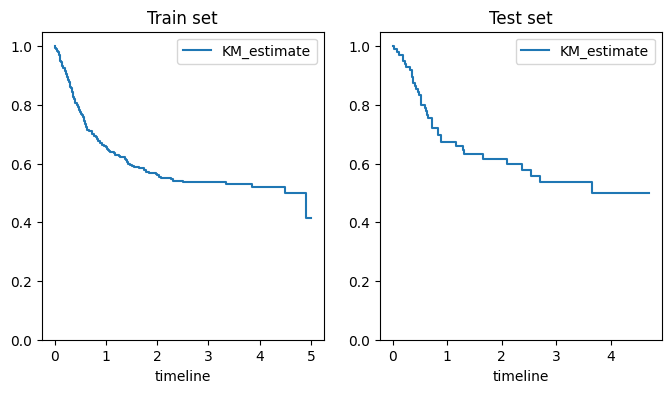

In [6]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (8,4))

km = lifelines.KaplanMeierFitter()
km.fit(y_train, delta_train)
km.plot(ax = ax[0], ci_show = False, show_censors = False)
ax[0].set_ylim(0,1.05)
ax[0].set_title("Train set")

km = lifelines.KaplanMeierFitter()
km.fit(y_test, delta_test)
km.plot(ax = ax[1], ci_show = False, show_censors = False)
ax[1].set_ylim(0,1.05)
ax[1].set_title("Test set")


plt.show()

### Poisson

In [7]:
data_train = [y_train, delta_train]
data_test = [y_test, delta_test]

poisson_spec = mpscr.MPSPoisson()
with tf.device("/CPU:0"):
    poisson_model = mpscr.build_mpscr_model(y_train, delta_train, (1,), poisson_spec, seed = 10, n_cuts = 5)
    poisson_model.pre_train_model(epochs = None, x = x_train[:,None], data = data_train, shuffle = True)
    poisson_model.train_model(epochs = 5000, x = x_train[:,None], data = data_train,
                              shuffle = True,
                              get_covariances = False,
                              validation = True, val_prop = 0.2, force_training_validation = False,
                              optimizer_independent = optimizers.Adam(learning_rate = 0.01),
                              optimizer_nn = optimizers.Adam(learning_rate = 0.01),
                              fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                              early_stopping = True, early_stopping_patience = 50,
                              early_stopping_warmup = 10, early_stopping_min_delta = 1.0e-3,
                              reduce_lr = True, reduce_lr_warmup = 0,
                              reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 25,
                              reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                              fine_tune = True,
                              finetune_early_stopping = True, finetune_early_stopping_patience = 50,
                              finetune_early_stopping_warmup = 10, finetune_early_stopping_min_delta = 1.0e-2,
                              finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                              finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-2, finetune_reduce_lr_patience = 25,
                              finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                              deterministic = True,
                              verbose = True, print_freq = 1)

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 96 / 5000 ]  | Avg. Train NLL:  0.606575608 | Avg. Validation NLL:  0.387243062 | Best Avg. Validation NLL:  0.371825755 | Speed:  0.00200032443  epoch/s    | Elapsed Time:  0.192031145  s    
Convergence criterion reached. Stopping.
Restoring best weights... / 5000 ]  | Avg. Train NLL:  0.606411099 | Avg. Validation NLL:  0.387398213 | Best Avg. Validation NLL:  0.371825755 | Speed:  0.00199660822  epoch/s    | Elapsed Time:  0.193670988  s   

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 157 / 5000 ]  | Avg. Train NLL:  0.600326538 | Best Avg. Train NLL:  0.600326538 | Avg. Validation NLL:  0.412441164 | Speed:  0.00263993302  epoch/s    | Elapsed Time:  0.414469481  s   
Convergence criterion reached. Stopping.
Restoring best weights...8 / 5000 ]  | Avg. Train NLL:  0.600321293 | Best Avg. Train NLL:  0.600321293 | Avg. Validation NLL:  0.412470788 | Spe

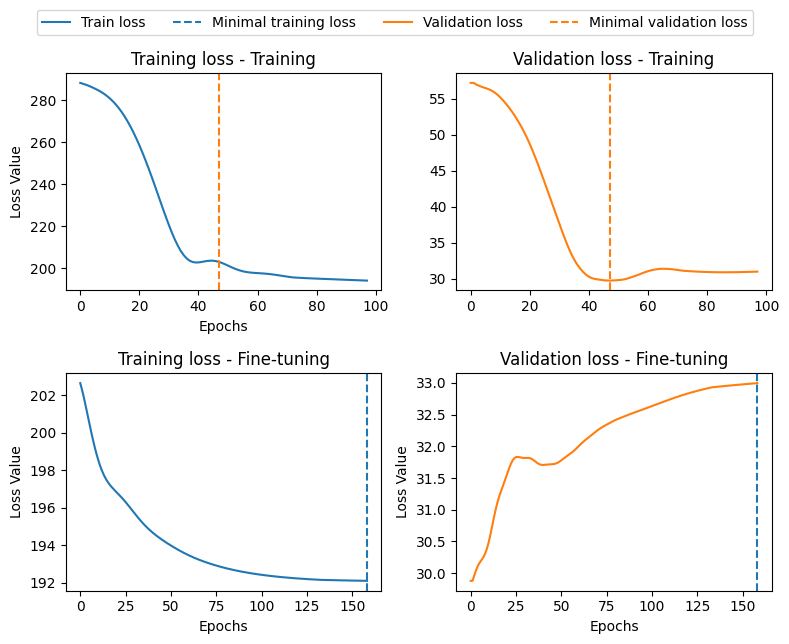

In [8]:
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (8,6))

utils.plot_model_convergence( poisson_model, ax1 = ax[0,0], ax2 = ax[0,1], ax3 = ax[1,0], ax4 = ax[1,1] )

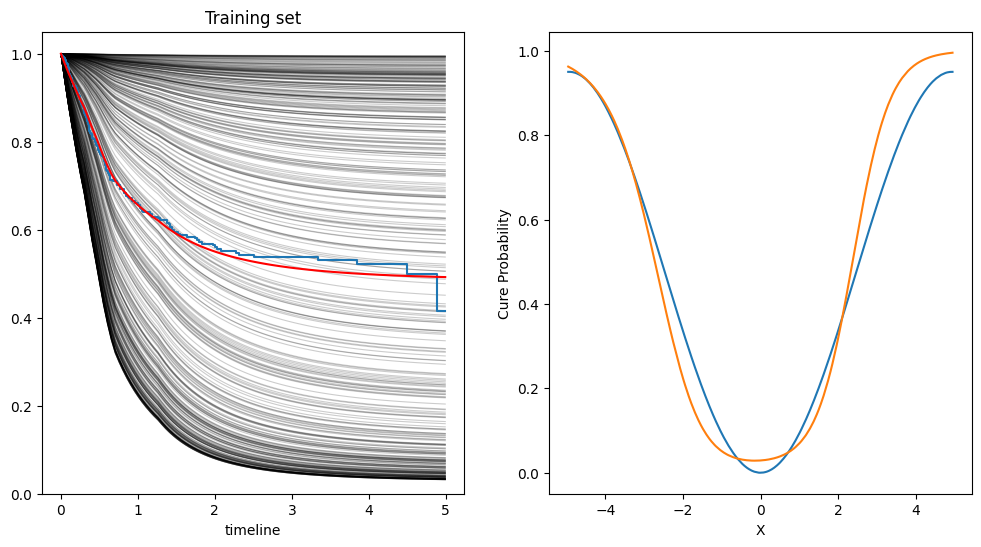

In [9]:
results_cure_poisson = poisson_model.get_survival_cure(y_train, x_train[:,None], y_test, x_test[:,None], ngrid = 100)

t = np.linspace(0.0001, np.max(np.concatenate([y_train, y_test])), 100)[:, None]

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

utils.average_kaplan_meier(results_cure_poisson["ts_grid"], results_cure_poisson["S_ts_train"],
                           y_train, delta_train, show_individual = True, ax = ax[0])
ax[0].get_legend().remove()

sns.lineplot(x = x_train, y = p_true_train, ax = ax[1])
sns.lineplot(x = x_train, y = results_cure_poisson["p_train"], ax = ax[1])
ax[1].set_xlabel("X")
ax[1].set_ylabel("Cure Probability")

plt.show()

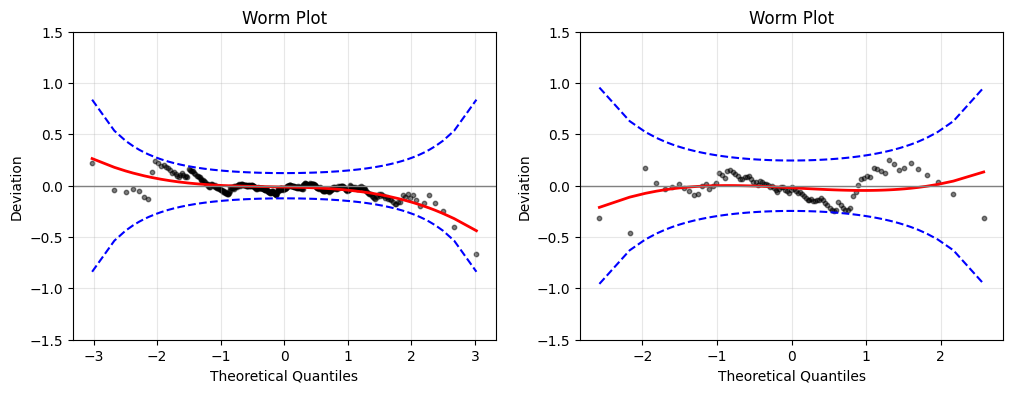

In [10]:
resid_train_poisson = utils.compute_randomized_residuals_censoring(results_cure_poisson["S_train"], delta_train)
resid_test_poisson = utils.compute_randomized_residuals_censoring(results_cure_poisson["S_test"], delta_test)

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,4))

utils.plot_worm( resid_train_poisson, ax = ax[0] )
utils.plot_worm( resid_test_poisson, ax = ax[1] )

# Fitting multiple models from the MPS

As shown above, the overall framework for the model is finished. Now, we are naturally interested in studying the behaviour of this model under misspecification. In particular, for this dataset, we considered the Poisson distribution as the generating process. Of all candidate models we can think in the MPS family, can we select the Poisson distributio as the winning model?

To do that, we incorporate the entire analysis from above into a single function, so we can obtain all the results for comparison using a single call.

In [11]:
def fit_model(dist,
              x_train, y_train, delta_train,
              x_test, y_test, delta_test,
              fixed_q = 0.0):
    '''
        Receives the name of a particular subfamily inside the two-parameter MPS family, fit the associated model
        and return all relevant results for this study.
    '''

    dist = dist.lower()
    if(dist == "poisson"):
        model_spec = mpscr.MPSPoisson()
    elif(dist == "bin" or dist == "binomial"):
        model_spec = mpscr.MPSBinomial(fixed_q)
    elif(dist == "negbin"):
        model_spec = mpscr.MPSNegBinomial()
    elif(dist == "log" or dist == "logarithmic"):
        model_spec = mpscr.MPSLogarithmic()
    else:
        raise Exception("Please, provide a valid subfamily name.")

    data_train = [y_train, delta_train]
    data_test = [y_test, delta_test]
    
    with tf.device("/CPU:0"):
        model = mpscr.build_mpscr_model(y_train, delta_train, (1,), model_spec, seed = 10, n_cuts = 5)
        model.pre_train_model(epochs = None, x = x_train[:,None], data = data_train, shuffle = True)
        model.train_model(epochs = 5000, x = x_train[:,None], data = data_train,
                                  shuffle = True,
                                  get_covariances = False,
                                  validation = True, val_prop = 0.2, force_training_validation = False,
                                  optimizer_independent = optimizers.Adam(learning_rate = 0.01),
                                  optimizer_nn = optimizers.Adam(learning_rate = 0.01),
                                  fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                                  early_stopping = True, early_stopping_patience = 50,
                                  early_stopping_warmup = 10, early_stopping_min_delta = 1.0e-3,
                                  reduce_lr = True, reduce_lr_warmup = 0,
                                  reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 25,
                                  reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                  fine_tune = True,
                                  finetune_early_stopping = True, finetune_early_stopping_patience = 50,
                                  finetune_early_stopping_warmup = 10, finetune_early_stopping_min_delta = 1.0e-2,
                                  finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                                  finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-2, finetune_reduce_lr_patience = 25,
                                  finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                                  deterministic = True,
                                  verbose = True, print_freq = 1)

    results_cure_model = model.get_survival_cure(y_train, x_train[:,None], y_test, x_test[:,None], ngrid = 100)
    return model, results_cure_model

In [12]:
poisson_model, results_cure_poisson = fit_model("poisson", x_train, y_train, delta_train, x_test, y_test, delta_test)
results_cure_poisson["resid_train"] = utils.compute_randomized_residuals_censoring(results_cure_poisson["S_train"], delta_train)
results_cure_poisson["resid_test"] = utils.compute_randomized_residuals_censoring(results_cure_poisson["S_test"], delta_test)

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 96 / 5000 ]  | Avg. Train NLL:  0.606575608 | Avg. Validation NLL:  0.387243062 | Best Avg. Validation NLL:  0.371825755 | Speed:  0.00174679363  epoch/s    | Elapsed Time:  0.167692184  s    
Convergence criterion reached. Stopping.
Optimizing... Epoch: [ 97 / 5000 ]  | Avg. Train NLL:  0.606411099 | Avg. Validation NLL:  0.387398213 | Best Avg. Validation NLL:  0.371825755 | Speed:  0.00175556447  epoch/s    | Elapsed Time:  0.170289755  s   Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 157 / 5000 ]  | Avg. Train NLL:  0.600326538 | Best Avg. Train NLL:  0.600326538 | Avg. Validation NLL:  0.412441164 | Speed:  0.0019836335  epoch/s    | Elapsed Time:  0.311430454  s    
Convergence criterion reached. Stopping.
Restoring best weights...8 / 5000 ]  | Avg. Train NLL:  0.600321293 | Best Avg. Train NLL:  0.600321293 | Avg. Validatio

### Binomial

In [13]:
bin5_model, results_cure_bin5 = fit_model("bin", x_train, y_train, delta_train, x_test, y_test, delta_test, fixed_q = 5)
results_cure_bin5["resid_train"] = utils.compute_randomized_residuals_censoring(results_cure_bin5["S_train"], delta_train)
results_cure_bin5["resid_test"] = utils.compute_randomized_residuals_censoring(results_cure_bin5["S_test"], delta_test)

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 101 / 5000 ]  | Avg. Train NLL:  0.602738559 | Avg. Validation NLL:  0.393631905 | Best Avg. Validation NLL:  0.378888935 | Speed:  0.00255489815  epoch/s    | Elapsed Time:  0.25804472  s    
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 113 / 5000 ]  | Avg. Train NLL:  0.604924798 | Best Avg. Train NLL:  0.604924798 | Avg. Validation NLL:  0.41110751 | Speed:  0.00191812601  epoch/s    | Elapsed Time:  0.216748238  s    
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Optimization finished in 3.828 seconds.


### Negative Binomial (Mean-Variance parametrization)

In [14]:
nb_model, results_cure_nb = fit_model("negbin", x_train, y_train, delta_train, x_test, y_test, delta_test, fixed_q = 5)
results_cure_nb["resid_train"] = utils.compute_randomized_residuals_censoring(results_cure_nb["S_train"], delta_train)
results_cure_nb["resid_test"] = utils.compute_randomized_residuals_censoring(results_cure_nb["S_test"], delta_test)

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 96 / 5000 ]  | Avg. Train NLL:  0.632225275 | Avg. Validation NLL:  0.398213774 | Best Avg. Validation NLL:  0.390190601 | Speed:  0.00214186567  epoch/s    | Elapsed Time:  0.205619097  s    
Convergence criterion reached. Stopping.
Optimizing... Epoch: [ 97 / 5000 ]  | Avg. Train NLL:  0.631858647 | Avg. Validation NLL:  0.398348659 | Best Avg. Validation NLL:  0.390190601 | Speed:  0.00213700463  epoch/s    | Elapsed Time:  0.207289457  s   Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 231 / 5000 ]  | Avg. Train NLL:  0.59871465 | Best Avg. Train NLL:  0.59871465 | Avg. Validation NLL:  0.419623673 | Speed:  0.00289426744  epoch/s    | Elapsed Time:  0.668575764  s     
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Optimization finished in 4.356 seconds.


### Logarithmic

In [15]:
log_model, results_cure_log = fit_model("log", x_train, y_train, delta_train, x_test, y_test, delta_test, fixed_q = 5)
results_cure_log["resid_train"] = utils.compute_randomized_residuals_censoring(results_cure_log["S_train"], delta_train)
results_cure_log["resid_test"] = utils.compute_randomized_residuals_censoring(results_cure_log["S_test"], delta_test)

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 101 / 5000 ]  | Avg. Train NLL:  0.715216815 | Avg. Validation NLL:  0.460394114 | Best Avg. Validation NLL:  0.458582401 | Speed:  0.00781410746  epoch/s    | Elapsed Time:  0.789224863  s   
Convergence criterion reached. Stopping.
Restoring best weights...2 / 5000 ]  | Avg. Train NLL:  0.714880109 | Avg. Validation NLL:  0.460381478 | Best Avg. Validation NLL:  0.458582401 | Speed:  0.00789117534  epoch/s    | Elapsed Time:  0.804899931  s   

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 396 / 5000 ]  | Avg. Train NLL:  0.653527677 | Best Avg. Train NLL:  0.653527677 | Avg. Validation NLL:  0.460142702 | Speed:  0.00851402804  epoch/s    | Elapsed Time:  3.37155509  s    
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Optimization finished in 7.697 seconds.


# Comparing all models

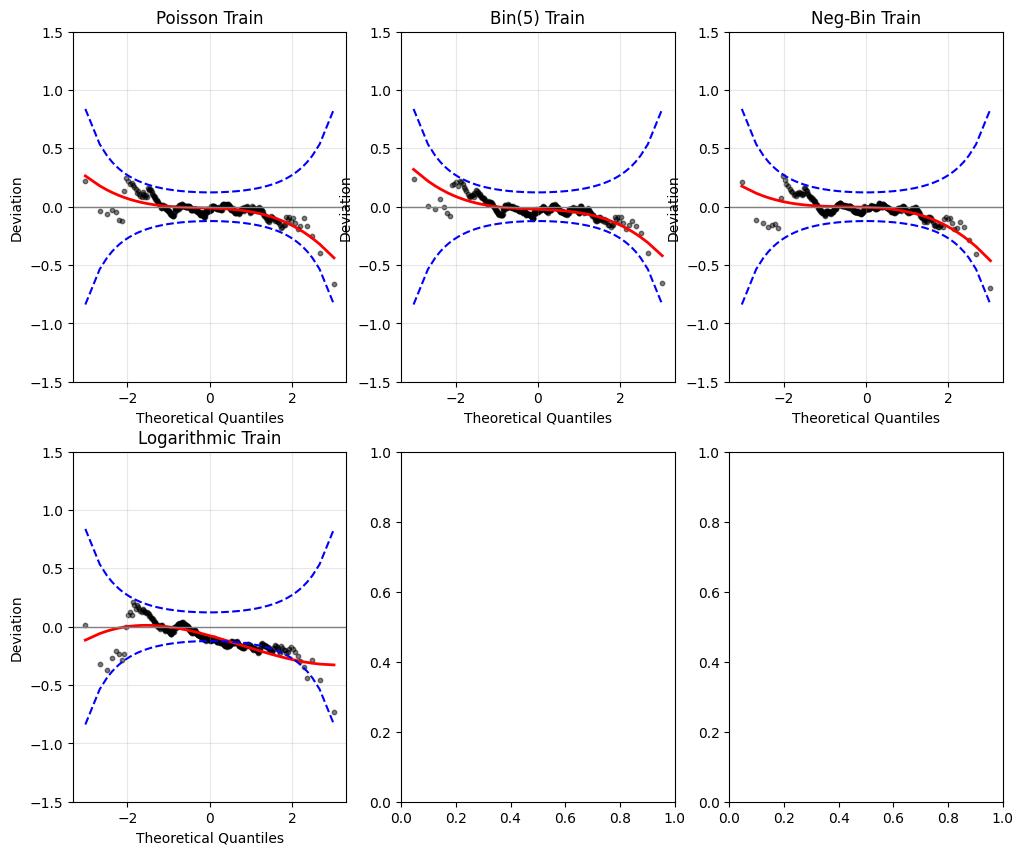

In [16]:
fig, ax = plt.subplots(nrows = 2, ncols = 3, figsize = (12,10))

utils.plot_worm( results_cure_poisson["resid_train"], ax = ax[0,0] )
ax[0,0].set_title("Poisson Train")
utils.plot_worm( results_cure_bin5["resid_train"], ax = ax[0,1] )
ax[0,1].set_title("Bin(5) Train")
utils.plot_worm( results_cure_nb["resid_train"], ax = ax[0,2] )
ax[0,2].set_title("Neg-Bin Train")
utils.plot_worm( results_cure_log["resid_train"], ax = ax[1,0] )
ax[1,0].set_title("Logarithmic Train")
plt.show()

In [17]:
from scipy.stats import anderson

In [18]:
ad_poisson = anderson( results_cure_poisson["resid_test"] ).statistic
ad_bin5 = anderson( results_cure_bin5["resid_test"] ).statistic
ad_nb = anderson( results_cure_nb["resid_test"] ).statistic
ad_log = anderson( results_cure_log["resid_test"] ).statistic

pd.DataFrame({"Set": ["Test", "Test", "Test", "Test"],
              "Model": ["Poisson", "Bin5", "NegBin", "Logarithmic"],
              "ad_statistic": [ad_poisson, ad_bin5, ad_nb, ad_log]})

,Set,Model,ad_statistic
0,Test,Poisson,0.659134
1,Test,Bin5,0.639487
2,Test,NegBin,0.663036
3,Test,Logarithmic,1.003668
